<a href="https://colab.research.google.com/github/Maryam-Shile/Intuitive_pythonista_projects/blob/main/My_first_zindi_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!unzip /content/financial-inclusion-in-africa20250311-22142-nbnoiv.zip -d /content/financial_inclusion

Archive:  /content/financial-inclusion-in-africa20250311-22142-nbnoiv.zip
  inflating: /content/financial_inclusion/manifest-e268f67161c155de502276443b494f7c20250311-22142-1qdfioo.json  
  inflating: /content/financial_inclusion/Train.csv  
  inflating: /content/financial_inclusion/Test.csv  
  inflating: /content/financial_inclusion/VariableDefinitions.csv  
  inflating: /content/financial_inclusion/SampleSubmission.csv  
  inflating: /content/financial_inclusion/StarterNotebook.ipynb  


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, RobustScaler

In [5]:
var_def = pd.read_csv('/content/financial_inclusion/VariableDefinitions.csv')
var_def

,Variable Definitions,Unnamed: 1
0,country,Country interviewee is in.
1,year,Year survey was done in.
2,uniqueid,Unique identifier for each interviewee
3,location_type,"Type of location: Rural, Urban"
4,cellphone_access,"If interviewee has access to a cellphone: Yes, No"
5,household_size,Number of people living in one house
6,age_of_respondent,The age of the interviewee
7,gender_of_respondent,"Gender of interviewee: Male, Female"
8,relationship_with_head,The interviewee’s relationship with the head o...
9,marital_status,The martial status of the interviewee: Married...


In [6]:
train_df = pd.read_csv('/content/financial_inclusion/Train.csv')
test_df = pd.read_csv('/content/financial_inclusion/Test.csv')
train_df

,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23519,Uganda,2018,uniqueid_2113,No,Rural,Yes,4,48,Female,Head of Household,Divorced/Seperated,No formal education,Other Income
23520,Uganda,2018,uniqueid_2114,No,Rural,Yes,2,27,Female,Head of Household,Single/Never Married,Secondary education,Other Income
23521,Uganda,2018,uniqueid_2115,No,Rural,Yes,5,27,Female,Parent,Widowed,Primary education,Other Income
23522,Uganda,2018,uniqueid_2116,No,Urban,Yes,7,30,Female,Parent,Divorced/Seperated,Secondary education,Self employed


In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23524 entries, 0 to 23523
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   country                 23524 non-null  object
 1   year                    23524 non-null  int64 
 2   uniqueid                23524 non-null  object
 3   bank_account            23524 non-null  object
 4   location_type           23524 non-null  object
 5   cellphone_access        23524 non-null  object
 6   household_size          23524 non-null  int64 
 7   age_of_respondent       23524 non-null  int64 
 8   gender_of_respondent    23524 non-null  object
 9   relationship_with_head  23524 non-null  object
 10  marital_status          23524 non-null  object
 11  education_level         23524 non-null  object
 12  job_type                23524 non-null  object
dtypes: int64(3), object(10)
memory usage: 2.3+ MB


In [8]:
train_df['uniqueid'] = train_df.uniqueid + ' x ' + train_df.country

train_df

,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1 x Kenya,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2 x Kenya,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3 x Kenya,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4 x Kenya,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5 x Kenya,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23519,Uganda,2018,uniqueid_2113 x Uganda,No,Rural,Yes,4,48,Female,Head of Household,Divorced/Seperated,No formal education,Other Income
23520,Uganda,2018,uniqueid_2114 x Uganda,No,Rural,Yes,2,27,Female,Head of Household,Single/Never Married,Secondary education,Other Income
23521,Uganda,2018,uniqueid_2115 x Uganda,No,Rural,Yes,5,27,Female,Parent,Widowed,Primary education,Other Income
23522,Uganda,2018,uniqueid_2116 x Uganda,No,Urban,Yes,7,30,Female,Parent,Divorced/Seperated,Secondary education,Self employed


In [9]:
test_df['uniqueid'] = test_df.uniqueid + ' x ' + test_df.country

test_df

,country,year,uniqueid,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_6056 x Kenya,Urban,Yes,3,30,Male,Head of Household,Married/Living together,Secondary education,Formally employed Government
1,Kenya,2018,uniqueid_6060 x Kenya,Urban,Yes,7,51,Male,Head of Household,Married/Living together,Vocational/Specialised training,Formally employed Private
2,Kenya,2018,uniqueid_6065 x Kenya,Rural,No,3,77,Female,Parent,Married/Living together,No formal education,Remittance Dependent
3,Kenya,2018,uniqueid_6072 x Kenya,Rural,No,6,39,Female,Head of Household,Married/Living together,Primary education,Remittance Dependent
4,Kenya,2018,uniqueid_6073 x Kenya,Urban,No,3,16,Male,Child,Single/Never Married,Secondary education,Remittance Dependent
...,...,...,...,...,...,...,...,...,...,...,...,...
10081,Uganda,2018,uniqueid_2998 x Uganda,Rural,No,2,62,Female,Spouse,Married/Living together,Primary education,Self employed
10082,Uganda,2018,uniqueid_2999 x Uganda,Urban,Yes,8,42,Male,Head of Household,Married/Living together,Primary education,Self employed
10083,Uganda,2018,uniqueid_3000 x Uganda,Urban,Yes,1,39,Male,Head of Household,Single/Never Married,Secondary education,Other Income
10084,Uganda,2018,uniqueid_3001 x Uganda,Rural,Yes,6,28,Female,Spouse,Married/Living together,Primary education,Self employed


HOUSEHOLD SIZE

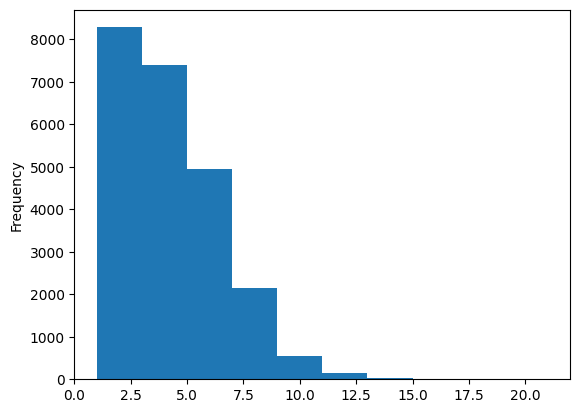

In [ ]:
train_df['household_size'].plot(kind = 'hist')
plt.show()

In [ ]:
train_df['household_size'].describe()

,household_size
count,23524.000000
mean,3.797483
std,2.227613
min,1.000000
25%,2.000000
50%,3.000000
75%,5.000000
max,21.000000


In [ ]:
#we are using standard scaler because the maximum number of household (21) is far from the mean which is around 4.
rs = RobustScaler()
train_df['household_size'] = rs.fit_transform(train_df[['household_size']])
train_df

,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1 x Kenya,Yes,Rural,Yes,0.000000,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2 x Kenya,No,Rural,No,0.666667,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3 x Kenya,Yes,Urban,Yes,0.666667,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4 x Kenya,No,Rural,Yes,0.666667,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5 x Kenya,No,Urban,No,1.666667,26,Male,Child,Single/Never Married,Primary education,Informally employed
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23519,Uganda,2018,uniqueid_2113 x Uganda,No,Rural,Yes,0.333333,48,Female,Head of Household,Divorced/Seperated,No formal education,Other Income
23520,Uganda,2018,uniqueid_2114 x Uganda,No,Rural,Yes,-0.333333,27,Female,Head of Household,Single/Never Married,Secondary education,Other Income
23521,Uganda,2018,uniqueid_2115 x Uganda,No,Rural,Yes,0.666667,27,Female,Parent,Widowed,Primary education,Other Income
23522,Uganda,2018,uniqueid_2116 x Uganda,No,Urban,Yes,1.333333,30,Female,Parent,Divorced/Seperated,Secondary education,Self employed


In [ ]:
test_df['household_size'] = rs.transform(test_df[['household_size']])
test_df

,country,year,uniqueid,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_6056 x Kenya,Urban,Yes,0.000000,30,Male,Head of Household,Married/Living together,Secondary education,Formally employed Government
1,Kenya,2018,uniqueid_6060 x Kenya,Urban,Yes,1.333333,51,Male,Head of Household,Married/Living together,Vocational/Specialised training,Formally employed Private
2,Kenya,2018,uniqueid_6065 x Kenya,Rural,No,0.000000,77,Female,Parent,Married/Living together,No formal education,Remittance Dependent
3,Kenya,2018,uniqueid_6072 x Kenya,Rural,No,1.000000,39,Female,Head of Household,Married/Living together,Primary education,Remittance Dependent
4,Kenya,2018,uniqueid_6073 x Kenya,Urban,No,0.000000,16,Male,Child,Single/Never Married,Secondary education,Remittance Dependent
...,...,...,...,...,...,...,...,...,...,...,...,...
10081,Uganda,2018,uniqueid_2998 x Uganda,Rural,No,-0.333333,62,Female,Spouse,Married/Living together,Primary education,Self employed
10082,Uganda,2018,uniqueid_2999 x Uganda,Urban,Yes,1.666667,42,Male,Head of Household,Married/Living together,Primary education,Self employed
10083,Uganda,2018,uniqueid_3000 x Uganda,Urban,Yes,-0.666667,39,Male,Head of Household,Single/Never Married,Secondary education,Other Income
10084,Uganda,2018,uniqueid_3001 x Uganda,Rural,Yes,1.000000,28,Female,Spouse,Married/Living together,Primary education,Self employed


AGE

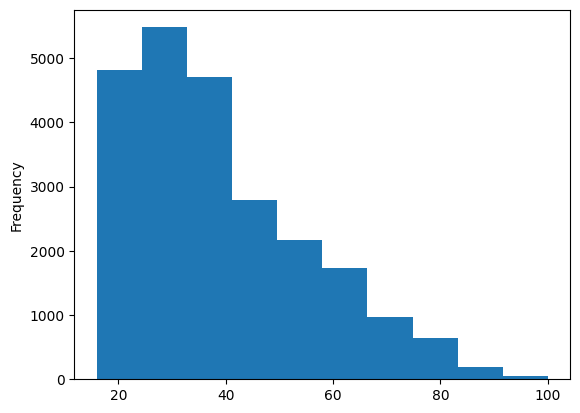

In [ ]:
train_df['age_of_respondent'].plot(kind = 'hist')
plt.show()

In [ ]:
train_df['age_of_respondent'].describe()

,age_of_respondent
count,23524.000000
mean,38.805220
std,16.520569
min,16.000000
25%,26.000000
50%,35.000000
75%,49.000000
max,100.000000


In [ ]:
age_boundaries = [0, 18, 25, 35, 45, 55, 65, np.inf]
labels = ['minors', 'gen_z', 'young_professionals', 'family_formers', 'mature_adults', 'pre_retirement', 'seniors']
train_df['age_group'] = pd.cut(x = train_df['age_of_respondent'], bins = age_boundaries, labels = labels, right = False)
train_df

,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type,age_group
0,Kenya,2018,uniqueid_1 x Kenya,Yes,Rural,Yes,0.000000,24,Female,Spouse,Married/Living together,Secondary education,Self employed,gen_z
1,Kenya,2018,uniqueid_2 x Kenya,No,Rural,No,0.666667,70,Female,Head of Household,Widowed,No formal education,Government Dependent,seniors
2,Kenya,2018,uniqueid_3 x Kenya,Yes,Urban,Yes,0.666667,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed,young_professionals
3,Kenya,2018,uniqueid_4 x Kenya,No,Rural,Yes,0.666667,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private,young_professionals
4,Kenya,2018,uniqueid_5 x Kenya,No,Urban,No,1.666667,26,Male,Child,Single/Never Married,Primary education,Informally employed,young_professionals
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23519,Uganda,2018,uniqueid_2113 x Uganda,No,Rural,Yes,0.333333,48,Female,Head of Household,Divorced/Seperated,No formal education,Other Income,mature_adults
23520,Uganda,2018,uniqueid_2114 x Uganda,No,Rural,Yes,-0.333333,27,Female,Head of Household,Single/Never Married,Secondary education,Other Income,young_professionals
23521,Uganda,2018,uniqueid_2115 x Uganda,No,Rural,Yes,0.666667,27,Female,Parent,Widowed,Primary education,Other Income,young_professionals
23522,Uganda,2018,uniqueid_2116 x Uganda,No,Urban,Yes,1.333333,30,Female,Parent,Divorced/Seperated,Secondary education,Self employed,young_professionals


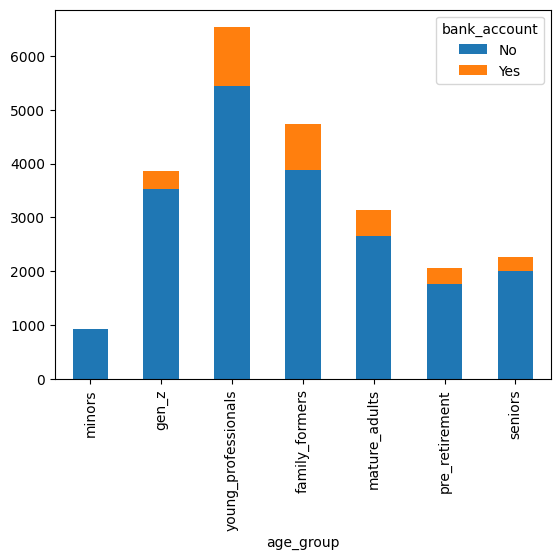

In [ ]:
bank_age = pd.crosstab(train_df['age_group'], train_df['bank_account'])
bank_age.plot(kind ='bar', stacked = True)
plt.show()

YEAR

In [ ]:
train_df['year'].value_counts()

,count
year,
2016,8735
2018,8169
2017,6620


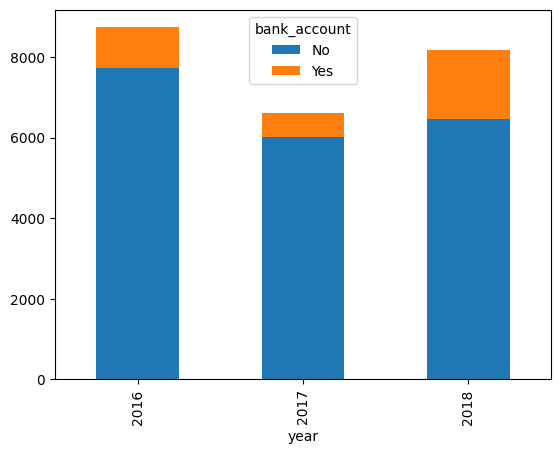

In [ ]:
account_per_year = pd.crosstab(train_df['year'], train_df['bank_account'])
account_per_year.plot(kind='bar', stacked =True)
plt.show()

Because the years show no trends, they will be treated as categorical

In [ ]:
train_df['year'] = train_df['year'].astype(str)
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23524 entries, 0 to 23523
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   country                 23524 non-null  object  
 1   year                    23524 non-null  object  
 2   uniqueid                23524 non-null  object  
 3   bank_account            23524 non-null  object  
 4   location_type           23524 non-null  object  
 5   cellphone_access        23524 non-null  object  
 6   household_size          23524 non-null  float64 
 7   age_of_respondent       23524 non-null  int64   
 8   gender_of_respondent    23524 non-null  object  
 9   relationship_with_head  23524 non-null  object  
 10  marital_status          23524 non-null  object  
 11  education_level         23524 non-null  object  
 12  job_type                23524 non-null  object  
 13  age_group               23524 non-null  category
dtypes: category(1), float6

In [ ]:
test_df['year'] = test_df['year'].astype(str)
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10086 entries, 0 to 10085
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   country                 10086 non-null  object 
 1   year                    10086 non-null  object 
 2   uniqueid                10086 non-null  object 
 3   location_type           10086 non-null  object 
 4   cellphone_access        10086 non-null  object 
 5   household_size          10086 non-null  float64
 6   age_of_respondent       10086 non-null  int64  
 7   gender_of_respondent    10086 non-null  object 
 8   relationship_with_head  10086 non-null  object 
 9   marital_status          10086 non-null  object 
 10  education_level         10086 non-null  object 
 11  job_type                10086 non-null  object 
dtypes: float64(1), int64(1), object(10)
memory usage: 945.7+ KB


SPLIT INTO INDEPENDENT AND TARGET VARIABLES

In [ ]:
from sklearn.model_selection import train_test_split
X = train_df.drop(columns = ['bank_account', 'age_group', 'uniqueid'])
y = train_df['bank_account']
X_test = test_df.drop(columns = ['uniqueid'])

In [ ]:
y = y.map({'Yes': 1, 'No': 0})
y

,bank_account
0,1
1,0
2,1
3,0
4,0
...,...
23519,0
23520,0
23521,0
23522,0


ENCODE THE CATEGORICAL VARIABLES IN X

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23524 entries, 0 to 23523
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   country                 23524 non-null  object 
 1   year                    23524 non-null  object 
 2   location_type           23524 non-null  object 
 3   cellphone_access        23524 non-null  object 
 4   household_size          23524 non-null  float64
 5   age_of_respondent       23524 non-null  int64  
 6   gender_of_respondent    23524 non-null  object 
 7   relationship_with_head  23524 non-null  object 
 8   marital_status          23524 non-null  object 
 9   education_level         23524 non-null  object 
 10  job_type                23524 non-null  object 
dtypes: float64(1), int64(1), object(9)
memory usage: 2.0+ MB


In [ ]:
from sklearn.compose import ColumnTransformer

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [ ]:
cat_variables = ['country', 'year', 'location_type',
       'cellphone_access', 'gender_of_respondent', 'relationship_with_head', 'marital_status',
       'education_level', 'job_type']
preprocessor = ColumnTransformer(transformers = [('cat', OneHotEncoder(drop ='first', sparse_output = False), cat_variables)], remainder = 'passthrough')

X_train_encoded = preprocessor.fit_transform(X_train)
X_val_encoded = preprocessor.transform(X_val)
X_test_encoded = preprocessor.transform(X_test)

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

iTERATE TO GET THE BEST PERFORMER FOR TUNING

In [ ]:
scoring_metrics = ['accuracy', 'f1']

models = {'Logistic Regression': LogisticRegression(max_iter = 1000, random_state = 42),
          'Random Forest': RandomForestClassifier(random_state = 42),
          'LGBM Classifier': LGBMClassifier(verbosity = -1, random_state = 42),
          'XG Boost': XGBClassifier(random_state = 42),
          'Light GBM': LGBMClassifier(random_state = 42),
          'Gradient Boost': GradientBoostingClassifier(random_state = 42)}

results = []

for name, model in models.items():
  scores = cross_validate(model, X_train_encoded, y_train, cv = 5, scoring = scoring_metrics)
  mean_accuracy = np.mean(scores['test_accuracy'])
  mean_f1 = np.mean(scores['test_f1'])

  results.append({'Model': name, 'Accuracy_score': mean_accuracy, 'F1_score': mean_f1})


results = pd.DataFrame(results)
results

,Model,Accuracy_score,F1_score
0,Logistic Regression,0.884532,0.452962
1,Random Forest,0.865615,0.447470
2,LGBM Classifier,0.885010,0.475242
3,XG Boost,0.882194,0.472415
4,Light GBM,0.885010,0.475242
5,Gradient Boost,0.887242,0.454217


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {'num_leaves': [45, 57, 67, 75],
              'max_depth': [8, 10, 12],
              'min_data_in_leaf': [20, 50, 100],
              'learning_rate': [0.01, 0.03, 0.05],
              'is_unbalance': [True]}

grid = GridSearchCV(LGBMClassifier(random_state = 42), param_grid, cv = 5, scoring = 'f1', verbose = 1, n_jobs = -1)
grid.fit(X_train_encoded, y_train)

print(f'Best parameters: {grid.best_params_}')
print(f'Best Score: {grid.best_score_}')

Fitting 5 folds for each of 108 candidates, totalling 540 fits


KeyboardInterrupt: 

In [ ]:
param_grid = {'num_leaves': [75, 81, 87],
              'max_depth': [12, 14, 16],
              'min_data_in_leaf': [20, 50, 100],
              'learning_rate': [0.01],
              'is_unbalance': [True]}

grid = GridSearchCV(LGBMClassifier(random_state = 42), param_grid, cv = 5, scoring = 'f1', verbose = 1, n_jobs = -1)
grid.fit(X_train_encoded, y_train)

print(f'Best parameters: {grid.best_params_}')
print(f'Best Score: {grid.best_score_}')

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 2670, number of negative: 16149
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003743 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 161
[LightGBM] [Info] Number of data points in the train set: 18819, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.141878 -> initscore=-1.799780
[LightGBM] [Info] Start training from score -1.799780
Best parameters: {'is_unbalance': True, 'learning_rate': 0.01, 'max_depth': 12, 'min_data_in_leaf': 20, 'num_leaves': 75}
Best Score: nan


In [ ]:
final_model = grid.best_estimator_

In [ ]:
prediction = final_model.predict(X_val_encoded)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_val, prediction))

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
              precision    recall  f1-score   support

          No       0.93      0.92      0.93      4063
         Yes       0.53      0.55      0.54       642

    accuracy                           0.87      4705
   macro avg       0.73      0.74      0.73      4705
weighted avg       0.87      0.87      0.87      4705



In [ ]:
final_prediction = final_model.predict(X_test_encoded)
final_prediction

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20


array(['Yes', 'Yes', 'No', ..., 'Yes', 'No', 'No'], dtype=object)

In [ ]:
final_submission = pd.DataFrame({'uniqueid': test_df['uniqueid'], 'bank_account': final_prediction})
final_submission['bank_account'] = final_submission['bank_account'].map({'Yes': 1, 'No': 0})
final_submission

,uniqueid,bank_account
0,uniqueid_6056 x Kenya,1
1,uniqueid_6060 x Kenya,1
2,uniqueid_6065 x Kenya,0
3,uniqueid_6072 x Kenya,0
4,uniqueid_6073 x Kenya,0
...,...,...
10081,uniqueid_2998 x Uganda,0
10082,uniqueid_2999 x Uganda,0
10083,uniqueid_3000 x Uganda,1
10084,uniqueid_3001 x Uganda,0


In [ ]:
final_submission.to_csv('first_submission.csv', index = False)

In [ ]:
test_df

,country,year,uniqueid,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_6056 x Kenya,Urban,Yes,3,30,Male,Head of Household,Married/Living together,Secondary education,Formally employed Government
1,Kenya,2018,uniqueid_6060 x Kenya,Urban,Yes,7,51,Male,Head of Household,Married/Living together,Vocational/Specialised training,Formally employed Private
2,Kenya,2018,uniqueid_6065 x Kenya,Rural,No,3,77,Female,Parent,Married/Living together,No formal education,Remittance Dependent
3,Kenya,2018,uniqueid_6072 x Kenya,Rural,No,6,39,Female,Head of Household,Married/Living together,Primary education,Remittance Dependent
4,Kenya,2018,uniqueid_6073 x Kenya,Urban,No,3,16,Male,Child,Single/Never Married,Secondary education,Remittance Dependent
...,...,...,...,...,...,...,...,...,...,...,...,...
10081,Uganda,2018,uniqueid_2998 x Uganda,Rural,No,2,62,Female,Spouse,Married/Living together,Primary education,Self employed
10082,Uganda,2018,uniqueid_2999 x Uganda,Urban,Yes,8,42,Male,Head of Household,Married/Living together,Primary education,Self employed
10083,Uganda,2018,uniqueid_3000 x Uganda,Urban,Yes,1,39,Male,Head of Household,Single/Never Married,Secondary education,Other Income
10084,Uganda,2018,uniqueid_3001 x Uganda,Rural,Yes,6,28,Female,Spouse,Married/Living together,Primary education,Self employed
